[ 0.15173545  4.61716932  5.31284275  9.94906992 16.55172729 17.70986773
 17.87096903 21.03059067 28.65196521 30.19468414 34.84129683 37.64809268
 41.97651549 42.85156852 44.92811808 46.57622723]
[48.04778673  3.92372303  3.30178926 11.659101   35.28760224  7.97198744
  6.77303713  9.34784136 47.72014764 40.51046695 26.41089251  3.07744935
  9.36525984 43.22157964  2.37324827 42.07846934]
[-2.61810848e-03  1.92272292e-01 -3.55631025e+00  3.10748664e+01]
Slope: 0.16504012134489748, Intercept: 17.18199974549331
Mean Squared Error: 306.3409
R-squared: 0.0196
Mean Squared Error: 271.8439
R-squared: 0.1300
cubic is a better approximation by MSE
cubic is a better approximation by r^2


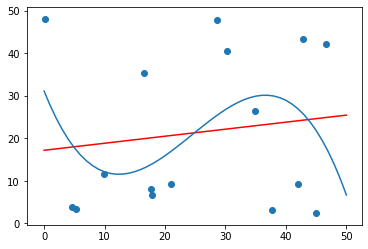

In [71]:
import numpy as np
import random
import matplotlib.pyplot as plt

X = np.zeros(np.random.randint(10,20))
for i in range(0, len(X)):
    X[i] = np.random.uniform(0,50)
X = np.sort(X)
print(X)

X3=X
Y = np.zeros(len(X))
for i in range(0, len(Y)):
    Y[i] = np.random.uniform(0,50)
print(Y)
Y3=Y
# Stack the design matrix with a column of ones (for the intercept)
A = np.vstack([X, np.ones(len(X))]).T

# Solve using least squares
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
coefficients = np.polyfit(X, Y, 3)
print(coefficients)
print(f"Slope: {m}, Intercept: {c}")
xlin = np.linspace(0, 50, 51)

plt.plot(xlin, xlin*m + c, 'r-')
plt.plot(xlin, coefficients[3] + coefficients[2]*xlin + coefficients[1]*xlin**2 + coefficients[0]*xlin**3)
plt.scatter(X, Y)

# linear errors
mse_linear = np.mean((Y - (X*m + c))**2)
print(f'Mean Squared Error: {mse_linear:.4f}')

ss_total_l = np.sum((Y - np.mean(Y))**2)
ss_res_l = np.sum((Y - (X*m + c))**2)
r_squared_l = 1 - (ss_res_l / ss_total_l)
print(f'R-squared: {r_squared_l:.4f}')

# cubic errors
mse_cubic = np.mean((Y - (coefficients[3] + coefficients[2]*X + coefficients[1]*X**2 + coefficients[0]*X**3))**2)
print(f'Mean Squared Error: {mse_cubic:.4f}')

ss_total_c = np.sum((Y - np.mean(Y))**2)
ss_res_c = np.sum((Y - (coefficients[3] + coefficients[2]*X + coefficients[1]*X**2 + coefficients[0]*X**3))**2)
r_squared_c = 1 - (ss_res_c / ss_total_c)
print(f'R-squared: {r_squared_c:.4f}')

if mse_linear > mse_cubic:
    print('cubic is a better approximation by MSE')
else:
    print('linear is a better approximation by MSE')
    
if r_squared_l > r_squared_c:
    print('linear is a better approximation by r^2')
else:
    print('cubic is a better approximation by r^2')

In [72]:
X = np.zeros(np.random.randint(10,20))
for i in range(0, len(X)):
    X[i] = np.random.uniform(0,50)
X = np.sort(X)
print(X)

Y = np.zeros(len(X))
for i in range(0, len(Y)):
    Y[i] = np.random.uniform(0,50)
print(Y)
# Stack the design matrix with a column of ones (for the intercept)
A = np.vstack([X, np.ones(len(X))]).T

# Solve using least squares
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]

# linear errors
mse_linear = np.mean((Y - (X*m + c))**2)
print(f'Mean Squared Error: {mse_linear:.4f}', 'linear')

ss_total_l = np.sum((Y - np.mean(Y))**2)
ss_res_l = np.sum((Y - (X*m + c))**2)
r_squared_l = 1 - (ss_res_l / ss_total_l)
print(f'R-squared: {r_squared_l:.4f}', 'linear')

for i in range (3, len(X)+1):
    coefficients = np.polyfit(X, Y, i)
    polynomial = np.poly1d(coefficients)
    y_pred = polynomial(X)

    mse_cubic = np.mean((Y-y_pred)**2)
    print(f'Mean Squared Error: {mse_cubic:.4f}', '@ degree', i)
    ss_total_c = np.sum((Y - np.mean(Y))**2)
    ss_res_c = np.sum((Y - (y_pred))**2)
    r_squared_c = 1 - (ss_res_c / ss_total_c)
    print(f'R-squared: {r_squared_c:.4f}', '@ degree', i)
    
for i in range (1, 3):
    coefficients = np.polyfit(X, Y, i)
    polynomial = np.poly1d(coefficients)
    y_pred = polynomial(X)

    mse_cubic = np.mean((Y-y_pred)**2)
    print(f'Mean Squared Error: {mse_cubic:.4f}', '@ degree', i)
    ss_total_c = np.sum((Y - np.mean(Y))**2)
    ss_res_c = np.sum((Y - (y_pred))**2)
    r_squared_c = 1 - (ss_res_c / ss_total_c)
    print(f'R-squared: {r_squared_c:.4f}', '@ degree', i)

[ 2.28715613  3.25768394  6.00213466  9.38258519  9.4656165  12.24123973
 12.85129034 15.06600963 18.17677893 18.31667873 26.03195316 31.12615657
 32.55005714 33.03368767 40.82286955 48.61145486]
[21.85080625 11.40319673 22.58245204 24.98086915 17.28701551  4.75532847
 32.75895896 14.9809367  29.35935427 24.38047192  9.14280698 23.76219816
  8.04722677 48.39336579 24.53413186 25.36491283]
Mean Squared Error: 102.7697 linear
R-squared: 0.0544 linear
Mean Squared Error: 102.7033 @ degree 3
R-squared: 0.0551 @ degree 3
Mean Squared Error: 101.7283 @ degree 4
R-squared: 0.0640 @ degree 4
Mean Squared Error: 101.6733 @ degree 5
R-squared: 0.0645 @ degree 5
Mean Squared Error: 97.6174 @ degree 6
R-squared: 0.1019 @ degree 6
Mean Squared Error: 88.1043 @ degree 7
R-squared: 0.1894 @ degree 7
Mean Squared Error: 73.6631 @ degree 8
R-squared: 0.3222 @ degree 8
Mean Squared Error: 73.3159 @ degree 9
R-squared: 0.3254 @ degree 9
Mean Squared Error: 71.8930 @ degree 10
R-squared: 0.3385 @ degree 1

/opt/conda/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3326: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)
/opt/conda/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3326: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)


This is noticeably different every time, but it seems that the polynomial very quickly overfits. This is random noise, so there is no way anything above r^2 of 0.2/0.3 should make any sense. Also, hitting the r^2 of 1 and MSE of 0 means that every single point is literally on the polynomial which is absurd. It is of note that this typically occurs at degree = length of X vector, which makes sense because that means there are enough degrees to hit every single point. Degree 1 typically appears underfit.

Mean Squared Error: 271.8439
R-squared: 0.1300


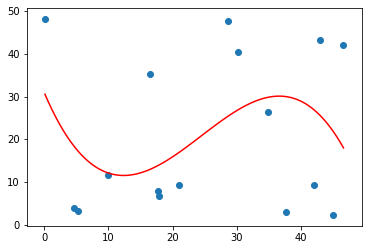

In [73]:
X = X3
Y = Y3

degree = 3

V = np.vander(X, N=degree+1, increasing=True)

VT_V = np.dot(V.T, V)
VT_y = np.dot(V.T, Y)

coefficients = np.linalg.solve(VT_V, VT_y)

polynomial = np.poly1d(coefficients[::-1])
y_pred = polynomial(X)

xlin = np.linspace(np.min(X), np.max(X), 101)
plt.plot(xlin, polynomial(xlin), 'r-')
plt.scatter(X, Y)

mse_cubic = np.mean((Y-y_pred)**2)
print(f'Mean Squared Error: {mse_cubic:.4f}')
ss_total_c = np.sum((Y - np.mean(Y))**2)
ss_res_c = np.sum((Y - (y_pred))**2)
r_squared_c = 1 - (ss_res_c / ss_total_c)
print(f'R-squared: {r_squared_c:.4f}')